## Methods Used in Evacuation Research

### Comparison Table

| Method | Strengths | Weaknesses | Validation maturity |
|---|---|---|---|
| Social Force (SFM) | Captures local interactions, bottleneck effects, arching/clogging; interpretable mechanics | Parameter-sensitive; can misfit real high-stress flow unless calibrated | Medium-High |
| Cellular Automata / Floor-Field | Very fast, scalable, easy scenario sweeps | Grid artifacts; behavior realism can be crude without many extensions | Medium |
| Rule-based ABM | Flexible behavior logic, route choice, social interactions | Modeler-bias risk; rule explosion; calibration burden | Medium |
| Continuum/macroscopic (Hughes-type) | Efficient for very large crowds and strategic flow patterns | Coarse individual behavior, weaker local interaction fidelity | Medium |
| ORCA/RVO velocity-avoidance | Excellent real-time collision avoidance, decentralized | Not an evacuation behavior theory by itself; weak for panic/social decision dynamics | Low-Medium (for evac behavior) |
| Fire-coupled evac (e.g., FDS+Evac) | Couples smoke/fire + movement + decision processes; practical for engineering | Heavier setup; still needs strong scenario-specific V&V | High (engineering use) |
| Generative/LLM-augmented ABM (GABM-like) | Rich heterogeneous behavior, what-if social logic | Highest validation burden, reproducibility/explainability concerns | Low-Medium |

### Aims of this notebook
- To do literature research on further models and papers, and identify which is the most suitable approach to use for evacuation modelling
- As much as possible, compare the pros & cons as well as use papers that have based research on real life data.
- In doing so, provide more direction in which to better pivot and organise future simulation projects during this internship


### Paper 1: Sticco, Frank, Dorso (2020/2021) — Black Friday crowd video

**Reference**

Sticco, Frank, Dorso (2020/2021) 
*Social Force Model parameter testing and optimization using a high stress real-life situation*  
- arXiv: https://arxiv.org/abs/2007.06651  
- Physica A DOI: https://doi.org/10.1016/j.physa.2020.125299

**What is this paper about?**

Real video of a Nike store opening (South Africa, Nov 2017), treated as emergency-like high-stress ingress.

Model use: Escape-panic SFM; compared multiple literature parameter sets; then optimized contact-related parameters (k_t, k_n) with Differential Evolution.

Key finding: Lab-calibrated sets tended to evacuate too fast versus real video curve; physical-contact terms were critical in dense aggressive flow.

Strength: Strong reality check for high-stress crowding; explicitly shows calibration transfer problem.

Limitation: Single event/context; parameter non-uniqueness (different parameter combos fit similarly). Also not a real emergency - it's about the hype over a store opening & the crowd 'rushing in', not 'rushing out'

### What this paper did
- Used real video from a Black Friday store opening (South Africa, Nov 2017).
- Measured high ingress flow: **⟨J⟩ = 6.7 ± 0.8 persons/s**.
- Compared simulation curves against empirical ingress curve.
- Found standard/lab parameter sets can be too optimistic (simulated flow too fast).
- Optimized contact-related parameters (`k_t`, `k_n`) to better match empirical behavior.

### What we replicate here
- We reproduce the **calibration logic** (fit simulation to target flow/curve).
- Our local `pysocialforce` implementation does **not expose** `k_t`, `k_n` directly.
- So we calibrate available proxies:
  - `social_force.factor`
  - `obstacle_force.factor`
  - `panic_speed` (initial desired speed)
- Output metrics:
  - cumulative entrants over time
  - entrants per second (flow)
  - final entered fraction

In [16]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\kylet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
# 1.1: setup
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import toml

REPO = Path(r"C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation")
EXPERIMENTS = REPO / "experiments"
BASE_CONFIG = EXPERIMENTS / "example.toml"

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import pysocialforce as psf

np.random.seed(42)

**1.2: Geometry + Config Helpers**

This cell defines:
- a corridor/barrier geometry with a doorway (Black-Friday-style ingress bottleneck),
- temporary config writing (so we can sweep parameters),
- initialization helpers for starting crowd positions

In [18]:
def write_temp_config(
    base_config_path,
    social_force_factor=5.1,
    obstacle_force_factor=10.0,
    max_speed_multiplier=1.3,
    tau=0.5
):
    cfg = toml.load(base_config_path)

    cfg.setdefault("scene", {})
    cfg["scene"]["max_speed_multiplier"] = float(max_speed_multiplier)
    cfg["scene"]["tau"] = float(tau)

    cfg.setdefault("social_force", {})
    cfg["social_force"]["factor"] = float(social_force_factor)

    cfg.setdefault("obstacle_force", {})
    cfg["obstacle_force"]["factor"] = float(obstacle_force_factor)

    f = tempfile.NamedTemporaryFile(delete=False, suffix=".toml")
    tmp_path = Path(f.name)
    f.close()

    with open(tmp_path, "w", encoding="utf-8") as fp:
        toml.dump(cfg, fp)

    return tmp_path


def make_black_friday_obstacles(x_left=-10, x_right=10, half_height=4.0, door_width=2.0):
    # Corridor top/bottom + barrier at x=0 with doorway gap
    dh = door_width / 2.0
    return [
        [x_left, x_right,  half_height,  half_height],   # top wall
        [x_left, x_right, -half_height, -half_height],   # bottom wall
        [0.0, 0.0,  dh,  half_height],                   # barrier upper
        [0.0, 0.0, -half_height, -dh],                   # barrier lower
    ]


def sample_initial_left_side(n_agents, x_min=-9.0, x_max=-1.0, y_min=-3.7, y_max=3.7):
    return np.column_stack([
        np.random.uniform(x_min, x_max, n_agents),
        np.random.uniform(y_min, y_max, n_agents),
    ])

**1.3: Single Simulation Runner**

This cell runs one ingress simulation and records:
- cumulative entrants over time,
- instantaneous flow (persons/s),
- final entered fraction,
- optional sampled trajectories.

In [19]:
# Single simulation run (ingress flow tracking)
def run_black_friday_once(
    n_agents=120,
    door_width=2.0,
    panic_speed=2.2,
    social_force_factor=5.1,
    obstacle_force_factor=10.0,
    max_steps=300,
    tau=0.5,
    seed=42,
    record_traj=False,
    traj_every=10,
):
    np.random.seed(seed)

    obstacles = make_black_friday_obstacles(door_width=door_width)
    pos0 = sample_initial_left_side(n_agents=n_agents)

    goal = np.array([8.5, 0.0])  # inside store direction
    goals = np.tile(goal, (n_agents, 1))

    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = goal - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * panic_speed

    init = np.zeros((n_agents, 6), dtype=float)
    init[:, :2] = pos0
    init[:, 2:4] = vel0
    init[:, 4:6] = goals

    cfg_path = write_temp_config(
        BASE_CONFIG,
        social_force_factor=social_force_factor,
        obstacle_force_factor=obstacle_force_factor,
        tau=tau
    )

    sim = psf.Simulator(
        init,
        groups=None,
        obstacles=obstacles,
        config_file=cfg_path
    )

    # Use simulator step width as the true integration time.
    dt = float(sim.peds.step_width)

    # More robust threshold for doorway crossing.
    gate_x = 0.0
    crossed = np.zeros(n_agents, dtype=bool)
    prev_entered = 0

    rows = []
    traj_rows = []

    for step in range(max_steps + 1):
        cur_pos = sim.peds.pos()
        cur_x = cur_pos[:, 0]

        # Mark entered once agent reaches/passes gate_x.
        crossed = crossed | (cur_x >= gate_x)

        entered_count = int(crossed.sum())
        new_entries = entered_count - prev_entered
        prev_entered = entered_count

        rows.append({
            "step": step,
            "time_s": step * dt,
            "new_entries": new_entries,
            "entered_count": entered_count,
            "entered_fraction": entered_count / n_agents,
            "inst_flow_p_s": (new_entries / dt) if dt > 0 else np.nan,
            "x_max": float(cur_x.max()),
            "x_mean": float(cur_x.mean()),
        })

        if record_traj and (step % traj_every == 0):
            for i in range(n_agents):
                traj_rows.append({
                    "step": step,
                    "time_s": step * dt,
                    "agent_id": i,
                    "x": float(cur_pos[i, 0]),
                    "y": float(cur_pos[i, 1]),
                })

        if step < max_steps:
            sim.step(1)

    curve = pd.DataFrame(rows)
    traj = pd.DataFrame(traj_rows)

    # active ingress window
    active = curve[curve["entered_count"] > 0]
    if len(active) > 1:
        duration = active["time_s"].iloc[-1] - active["time_s"].iloc[0]
        total_entered_in_window = active["entered_count"].iloc[-1] - active["entered_count"].iloc[0]
        mean_flow_active = total_entered_in_window / duration if duration > 0 else np.nan
    else:
        mean_flow_active = np.nan

    summary = {
        "n_agents": n_agents,
        "door_width": door_width,
        "panic_speed": panic_speed,
        "social_force_factor": social_force_factor,
        "obstacle_force_factor": obstacle_force_factor,
        "max_steps": max_steps,
        "tau": tau,
        "dt": dt,
        "gate_x": gate_x,
        "final_entered_count": int(curve["entered_count"].iloc[-1]),
        "final_entered_fraction": float(curve["entered_fraction"].iloc[-1]),
        "mean_flow_active_p_s": float(mean_flow_active) if pd.notna(mean_flow_active) else np.nan,
        "peak_flow_p_s": float(curve["inst_flow_p_s"].max()),
        "max_x_reached": float(curve["x_max"].max()),
    }

    return curve, traj, summary


**1.4: Baseline Run**

This cell runs 1 reference simulation & plots:
1. Cumulative entered count vs time
2. Flow vs time, with paper benchmark band (6.7 ± 0.8 p/s).

Purpose: sanity check whetehr default parameters are too fast/slow

n_agents                  120.000000
door_width                  2.000000
panic_speed                 2.200000
social_force_factor         5.100000
obstacle_force_factor      10.000000
max_steps                 300.000000
tau                         0.500000
dt                          0.050000
gate_x                      0.000000
final_entered_count       120.000000
final_entered_fraction      1.000000
mean_flow_active_p_s        8.178694
peak_flow_p_s              60.000000
max_x_reached              11.157983
dtype: float64
Entered max: 120 | Max x reached: 11.157983138950295


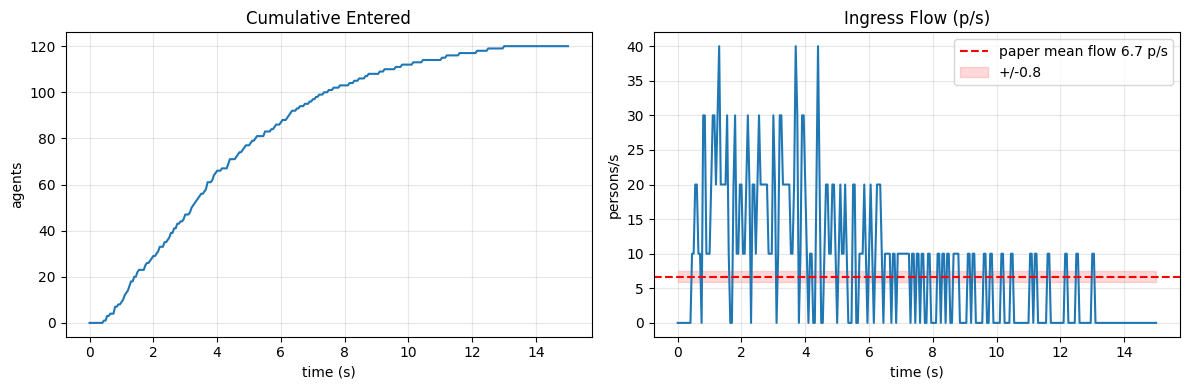

In [20]:
# 1.4: quick baseline run + visualize
curve0, traj0, s0 = run_black_friday_once(
    n_agents=120,
    door_width=2.0,
    panic_speed=2.2,
    social_force_factor=5.1,
    obstacle_force_factor=10.0,
    max_steps=300,
    tau=0.5,
    seed=101,
    record_traj=True,
    traj_every=10
)

print(pd.Series(s0))
print("Entered max:", int(curve0["entered_count"].max()), "| Max x reached:", float(curve0["x_max"].max()))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(curve0["time_s"], curve0["entered_count"])
ax[0].set_title("Cumulative Entered")
ax[0].set_xlabel("time (s)")
ax[0].set_ylabel("agents")
ax[0].grid(True, alpha=0.3)

flow_roll = curve0["inst_flow_p_s"].rolling(2, min_periods=1).mean()  # ~2*dt smoothing
ax[1].plot(curve0["time_s"], flow_roll)
ax[1].axhline(6.7, ls="--", c="r", label="paper mean flow 6.7 p/s")
ax[1].fill_between(curve0["time_s"], 5.9, 7.5, color="r", alpha=0.15, label="+/-0.8")
ax[1].set_title("Ingress Flow (p/s)")
ax[1].set_xlabel("time (s)")
ax[1].set_ylabel("persons/s")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**1.5: Calibration Sweep**

This cell performs a small parameter sweep over:
- `social_force_factor`,
- `obstacle_force_factor`,
- `panic_speed`.

It ranks candidates by absolute error to the benchmark flow (6.7 p/s).

In [21]:
# 1.5: calibration sweep (small and practical)
TARGET_FLOW = 6.7
TARGET_TOL = 0.8

grid_social = [4.0, 5.1, 6.5]
grid_obstacle = [8.0, 10.0, 12.0]
grid_speed = [1.8, 2.2, 2.8]
seeds = [101, 102]  # keep light first

rows = []
for sf in grid_social:
    for of in grid_obstacle:
        for sp in grid_speed:
            run_summaries = []
            for sd in seeds:
                _, _, summ = run_black_friday_once(
                    n_agents=120,
                    door_width=2.0,
                    panic_speed=sp,
                    social_force_factor=sf,
                    obstacle_force_factor=of,
                    max_steps=300,
                    tau=0.5,
                    seed=sd,
                    record_traj=False
                )
                run_summaries.append(summ)

            d = pd.DataFrame(run_summaries)
            mean_flow = d["mean_flow_active_p_s"].mean()
            mean_entered_frac = d["final_entered_fraction"].mean()

            rows.append({
                "social_force_factor": sf,
                "obstacle_force_factor": of,
                "panic_speed": sp,
                "mean_flow_active_p_s": mean_flow,
                "mean_final_entered_fraction": mean_entered_frac,
                "flow_abs_error_vs_6p7": abs(mean_flow - TARGET_FLOW) if pd.notna(mean_flow) else np.nan,
                "inside_target_band": (TARGET_FLOW - TARGET_TOL <= mean_flow <= TARGET_FLOW + TARGET_TOL) if pd.notna(mean_flow) else False
            })

calib = pd.DataFrame(rows).sort_values(["flow_abs_error_vs_6p7", "mean_final_entered_fraction"])
calib.head(10)

,social_force_factor,obstacle_force_factor,panic_speed,mean_flow_active_p_s,mean_final_entered_fraction,flow_abs_error_vs_6p7,inside_target_band
18,6.5,8.0,1.8,7.883043,0.966667,1.183043,False
24,6.5,12.0,1.8,7.883043,0.966667,1.183043,False
21,6.5,10.0,1.8,7.986373,0.979167,1.286373,False
9,5.1,8.0,1.8,8.020737,0.983333,1.320737,False
12,5.1,10.0,1.8,8.020737,0.983333,1.320737,False
15,5.1,12.0,1.8,8.034697,0.983333,1.334697,False
2,4.0,8.0,2.8,8.068517,1.000000,1.368517,False
5,4.0,10.0,2.8,8.068517,1.000000,1.368517,False
8,4.0,12.0,2.8,8.068517,1.000000,1.368517,False
20,6.5,8.0,2.8,8.075039,1.000000,1.375039,False


**1.6: Best Candidate + Trajectories**

This cell reruns the top candidate and visualizes:
- final calibration metrics,
- sample trajectories (“where agents go”) through the doorway.

Best candidate summary:
n_agents                  120.000000
door_width                  2.000000
panic_speed                 1.800000
social_force_factor         6.500000
obstacle_force_factor       8.000000
max_steps                 300.000000
tau                         0.500000
dt                          0.050000
gate_x                      0.000000
final_entered_count       117.000000
final_entered_fraction      0.975000
mean_flow_active_p_s        7.945205
peak_flow_p_s              40.000000
max_x_reached              11.495146
dtype: float64


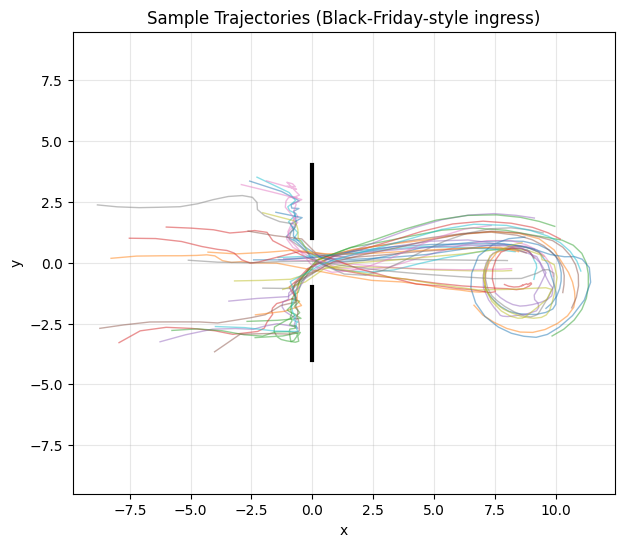

In [22]:
# 1.6: run best candidate and show trajectories ("where agents go")
best = calib.iloc[0]
curve_best, traj_best, summary_best = run_black_friday_once(
    n_agents=120,
    door_width=2.0,
    panic_speed=float(best["panic_speed"]),
    social_force_factor=float(best["social_force_factor"]),
    obstacle_force_factor=float(best["obstacle_force_factor"]),
    max_steps=300,
    tau=0.5,
    seed=999,
    record_traj=True,
    traj_every=10
)

print("Best candidate summary:")
print(pd.Series(summary_best))

# Sample trajectories
sample_agents = 30
ids = traj_best["agent_id"].drop_duplicates()
if len(ids) > sample_agents:
    ids = ids.sample(sample_agents, random_state=42)

plot_df = traj_best[traj_best["agent_id"].isin(ids)]

plt.figure(figsize=(7,6))
for aid, g in plot_df.groupby("agent_id"):
    plt.plot(g["x"], g["y"], alpha=0.5, lw=1)

# draw doorway lines
hh = 4.0
dw = 2.0
dh = dw / 2
plt.plot([0,0],[dh,hh],'k-',lw=3)
plt.plot([0,0],[-hh,-dh],'k-',lw=3)

plt.title("Sample Trajectories (Black-Friday-style ingress)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

**1.7: Summary and Findings**

- We replicated the **calibration idea** from Sticco et al. by fitting simulated flow to the empirical target band (6.7 ± 0.8 p/s).
- Because this local implementation does not expose `k_t` and `k_n`, calibration was performed on available force/speed parameters instead.
- The experiment still demonstrates the same core message:
  - default parameter sets may over/under-estimate high-stress throughput,
  - and multiple parameter combinations can produce similarly good aggregate fit (identifiability issue).
- Therefore, parameter fit should be reported with uncertainty and not treated as unique truth.